   total_bill   tip  size
0       16.99  1.01     2
1       10.34  1.66     3
2       21.01  3.50     3
3       23.68  3.31     2
4       24.59  3.61     4


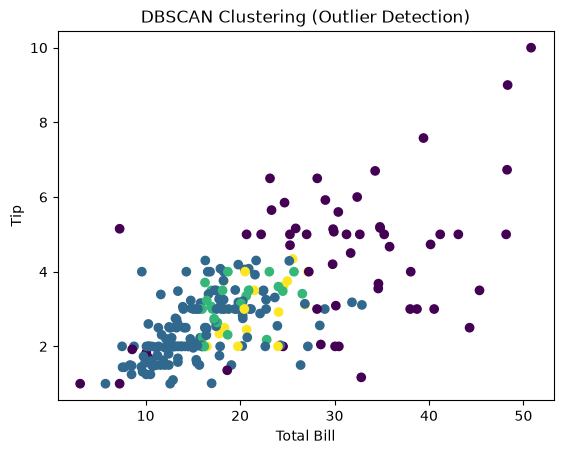

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

# 사용할 컬럼
df = df[["total_bill", "tip", "size"]]

print(df.head())



In [7]:
from sklearn.preprocessing import StandardScaler

x = df[["total_bill","tip","size"]]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [10]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.5, min_samples=5)
df["cluster"] = model.fit_predict(x_scaled)

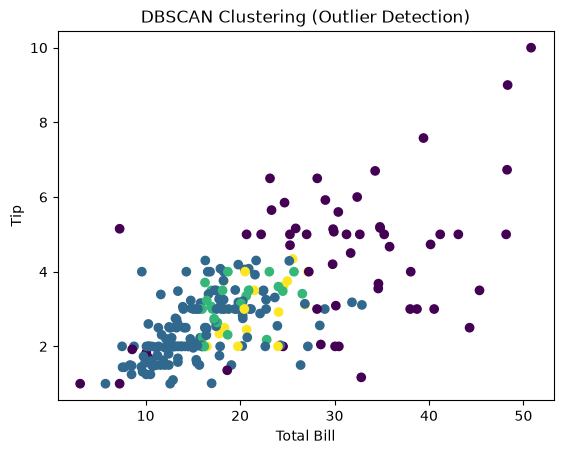

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["total_bill"], df["tip"], c=df["cluster"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Clustering (Outlier Detection)")
plt.show()

In [12]:
print(df["cluster"].value_counts())

cluster
 0    146
-1     56
 1     25
 2     17
Name: count, dtype: int64


In [13]:
print(df.groupby("cluster").mean(numeric_only=True))

# 분석
# 0 => 소규모 / 저가 소비 고객
# 1 => 중간 규모 / 일반 소비 고객
# 2 => 대규모 / 고가 소비 고객
# -1 => 이상치 고객 => 이것만 모아서 따로 분석 가능

         total_bill       tip      size
cluster                                
-1        29.986071  4.316250  3.428571
 0        15.720000  2.462123  2.000000
 1        19.352000  3.124400  3.000000
 2        21.742941  3.075882  4.000000


In [ ]:
# 2. DBSCAN 을 적용하여 아래와 같이 출력이 나오도록 하시오.
# 전처리시 정규화 적용 할것)

import numpy as np
import pandas as pd

np.random.seed(42)

# 정상 거래 (300건)
normal = np.random.normal(
    loc=[50, 10],     # 평균 [금액, 횟수]
    scale=[10, 3],    # 표준편차
    size=(300, 2)
)

# 이상 거래 (20건)
fraud = np.random.normal(
    loc=[200, 40],
    scale=[20, 8],
    size=(20, 2)
)

# 합치기
data = np.vstack([
    normal,
    fraud
])

# DataFrame 생성
df = pd.DataFrame(
    data,
    columns=[
        "amount",     # 결제금액
        "count"       # 결제횟수
    ]
)

print(df.head())

# 정규화
X = df[["amount", "count"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#DBSCAN
model = DBSCAN(
    eps=0.35,
    min_samples=5
)

model.fit(X_scaled)

df["cluster"] = model.labels_

print(df["cluster"].value_counts())


fraud_df = df[df["cluster"] == -1]  # 이상 거래만 보기 

print(fraud_df)

# =================================

# 0 → 정상 거래 그룹
# 1 → 다른 거래 패턴
# -1 → 이상 거래(의심)

# 출력)
# 0     296
# 1      18
# -1      6

# ======================================
# 이상 거래만 보기

# 출력)
# | amount | count | cluster |
# |    220 |    52 |      -1 |
# |    240 |    60 |      -1 |


      amount      count
0  54.967142   9.585207
1  56.476885  14.569090
2  47.658466   9.297589
3  65.792128  12.302304
4  45.305256  11.627680
cluster
 0    299
-1     21
Name: count, dtype: int64
         amount      count  cluster
104   55.150477  21.558194       -1
300  215.139772  32.622677       -1
301  217.392118  50.845103       -1
302  208.268698  55.014367       -1
303  184.524216  30.042762       -1
304  164.425595  51.968354       -1
305  213.087313  39.555323       -1
306  205.599373  30.996088       -1
307  248.915040  41.033769       -1
308  202.187896  45.806133       -1
309  209.620185  41.791072       -1
310  184.190511  43.771747       -1
311  237.640490  50.763360       -1
312  231.863733  35.910275       -1
313  180.207904  38.993705       -1
314  201.114498  48.753532       -1
315  166.150707  52.236403       -1
316  196.839842  36.584951       -1
317  179.757912  26.761147       -1
318  216.463412  40.586544       -1
319  174.200782  29.639370       -1



원본 데이터
      amount      count
0  54.967142   9.585207
1  56.476885  14.569090
2  47.658466   9.297589
3  65.792128  12.302304
4  45.305256  11.627680

그룹 개수
cluster
 0    300
-1     20
Name: count, dtype: int64

이상 거래
         amount      count  cluster
300  235.139772  42.622677       -1
301  237.392118  60.845103       -1
302  228.268698  65.014367       -1
303  204.524216  40.042762       -1
304  184.425595  61.968354       -1
305  233.087313  49.555323       -1
306  225.599373  40.996088       -1
307  268.915040  51.033769       -1
308  222.187896  55.806133       -1
309  229.620185  51.791072       -1
310  204.190511  53.771747       -1
311  257.640490  60.763360       -1
312  251.863733  45.910275       -1
313  200.207904  48.993705       -1
314  221.114498  58.753532       -1
315  186.150707  62.236403       -1
316  216.839842  46.584951       -1
317  199.757912  36.761147       -1
318  236.463412  50.586544       -1
319  194.200782  39.639370       -1

이상 거래 수: 20


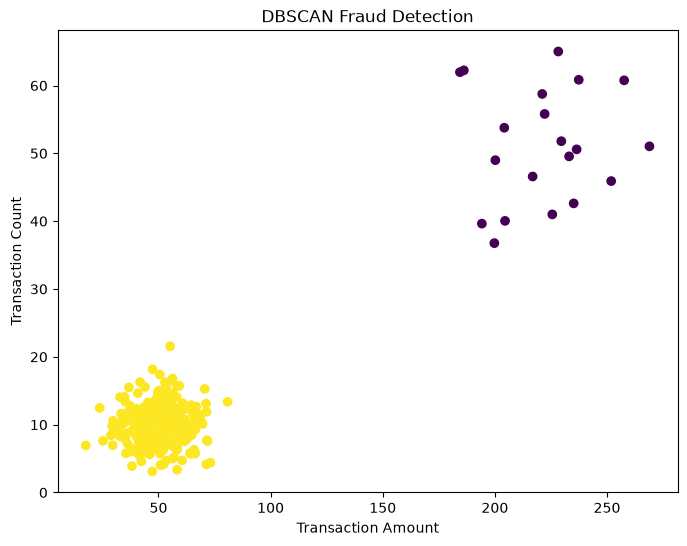

In [17]:
# ==========================
# 카드 이상 거래 탐지 (DBSCAN)
# ==========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


# --------------------------
# 1. 데이터 생성
# --------------------------

np.random.seed(42)

# 정상 거래 300건
normal = np.random.normal(
    loc=[50, 10],      # 평균 [금액, 횟수]
    scale=[10, 3],     # 표준편차
    size=(300, 2)
)

# 이상 거래 20건
fraud = np.random.normal(
    loc=[220, 50],
    scale=[20, 8],
    size=(20, 2)
)

# 합치기
data = np.vstack([
    normal,
    fraud
])


# --------------------------
# 2. DataFrame 생성
# --------------------------

df = pd.DataFrame(
    data,
    columns=[
        "amount",
        "count"
    ]
)

print("\n원본 데이터")
print(df.head())


# --------------------------
# 3. 표준화
# --------------------------

X = df[
    ["amount", "count"]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# --------------------------
# 4. DBSCAN
# --------------------------

model = DBSCAN(
    eps=0.38,
    min_samples=5
)

model.fit(X_scaled)


# --------------------------
# 5. 그룹 저장
# --------------------------

df["cluster"] = model.labels_


# --------------------------
# 6. 결과 확인
# --------------------------

print("\n그룹 개수")
print(
    df["cluster"].value_counts()
)


# --------------------------
# 7. 이상 거래 추출
# --------------------------

fraud_df = df[
    df["cluster"] == -1
]

print("\n이상 거래")
print(
    fraud_df
)


# --------------------------
# 8. 이상 거래 개수
# --------------------------

print(
    "\n이상 거래 수:",
    len(fraud_df)
)


# --------------------------
# 9. 시각화
# --------------------------

plt.figure(
    figsize=(8,6)
)

plt.scatter(
    df["amount"],
    df["count"],
    c=df["cluster"]
)

plt.xlabel(
    "Transaction Amount"
)

plt.ylabel(
    "Transaction Count"
)

plt.title(
    "DBSCAN Fraud Detection"
)

plt.show()